In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Extract zip
with zipfile.ZipFile('/content/archive (1).zip', 'r') as z:
    z.extractall('/content/')
    print("Files extracted:", z.namelist())

# Load dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Files extracted: ['Titanic-Dataset.csv']

Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.100

In [2]:
# Step 1: Keep only useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
# Survived → our TARGET (what we predict)
# rest → features (inputs)

# Step 2: Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
# fill missing Age with median

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# fill missing Embarked with most common port

# Step 3: Encode categorical columns
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
# male → 1, female → 0

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
# Embarked → Embarked_Q and Embarked_S

df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
# True/False → 1/0

print("Data after preprocessing:")
print(df.head())
print("\nShape:", df.shape)
print("\nNull values:", df.isnull().sum().sum())

Data after preprocessing:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0      1      0   7.2500           0           1
1         1       1    0  38.0      1      0  71.2833           0           0
2         1       3    0  26.0      0      0   7.9250           0           1
3         1       1    0  35.0      1      0  53.1000           0           1
4         0       3    1  35.0      0      0   8.0500           0           1

Shape: (891, 9)

Null values: 0


In [3]:
# Separate features and target
X = df.drop(columns=['Survived'])
# X → everything EXCEPT Survived (inputs)

Y = df['Survived']
# Y → only Survived column (what we predict)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Split into train and test
X_train, X_test, Y_train, Y_test = train_test_split(
                                   X, Y, test_size=0.2, random_state=42)
# 80% training, 20% testing
# random_state=42 → same split every time

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# fit_transform() → learns mean & std from TRAINING data
# then scales training data

X_test = scaler.transform(X_test)
# transform() → scales test data using SAME mean & std
# NOT fit_transform() → we never learn from test data!

print("\n✅ Features standardized successfully!")

X shape: (891, 8)
Y shape: (891,)

Training size: (712, 8)
Testing size: (179, 8)

✅ Features standardized successfully!


In [4]:
# Create the model
model = LogisticRegression(random_state=42)
# LogisticRegression() → creates an empty classifier
# random_state=42 → reproducible results

# Train the model
model.fit(X_train, Y_train)
# fit() → model LEARNS the relationship between
# features (X) and Survived (Y)

# Predict on test data
Y_pred = model.predict(X_test)
# predict() → predicts 0 or 1 for each test passenger

# Predict probabilities
Y_prob = model.predict_proba(X_test)[:, 1]
# predict_proba() → gives probability of survival (0.0 to 1.0)
# [:,1] → we take column 1 (probability of Survived=1)

print("Model trained successfully! ✅")
print("\nFirst 5 Actual:   ", list(Y_test[:5].values))
print("First 5 Predicted:", list(Y_pred[:5]))
print("First 5 Probabil.:", list(Y_prob[:5].round(2)))

Model trained successfully! ✅

First 5 Actual:    [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
First 5 Predicted: [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
First 5 Probabil.: [np.float64(0.11), np.float64(0.22), np.float64(0.13), np.float64(0.89), np.float64(0.75)]


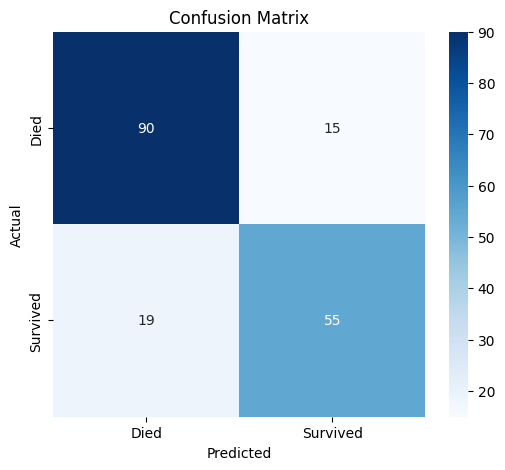


Confusion Matrix Values:
True Negative  (TN): 90
False Positive (FP): 15
False Negative (FN): 19
True Positive  (TP): 55


In [5]:
# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
# confusion_matrix() → shows how many predictions were
# correct and incorrect in a 2x2 table

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
# annot=True → shows numbers inside boxes
# fmt='d'    → shows as integers not decimals
# cmap='Blues' → blue color theme

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nConfusion Matrix Values:")
print(f"True Negative  (TN): {cm[0][0]}")
print(f"False Positive (FP): {cm[0][1]}")
print(f"False Negative (FN): {cm[1][0]}")
print(f"True Positive  (TP): {cm[1][1]}")

Classification Report:
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC Score: 0.88


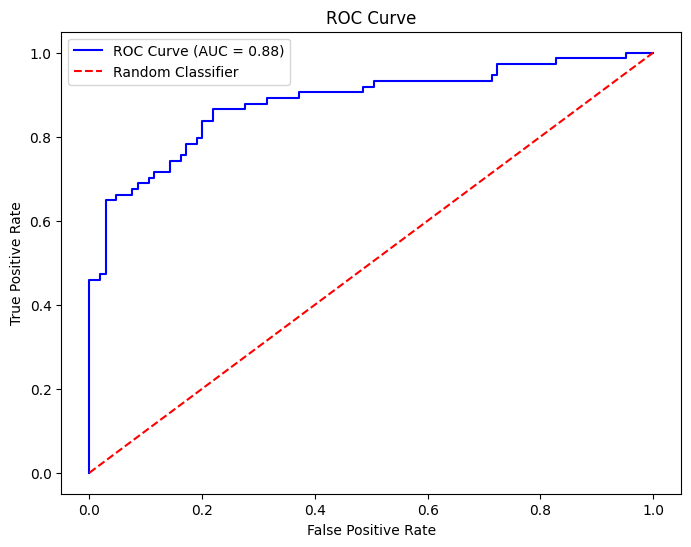

In [6]:
# Classification Report
print("Classification Report:")
print(classification_report(Y_test, Y_pred,
      target_names=['Died', 'Survived']))
# classification_report() → shows precision, recall, f1
# for each class separately

# ROC-AUC Score
roc_auc = roc_auc_score(Y_test, Y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
# roc_auc_score() → measures how well model separates
# survivors from non-survivors
# range: 0.5 (random) to 1.0 (perfect)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
# fpr → false positive rate at each threshold
# tpr → true positive rate at each threshold

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
# plots the ROC curve

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
# red diagonal line → represents a RANDOM/useless model
# our model should be ABOVE this line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

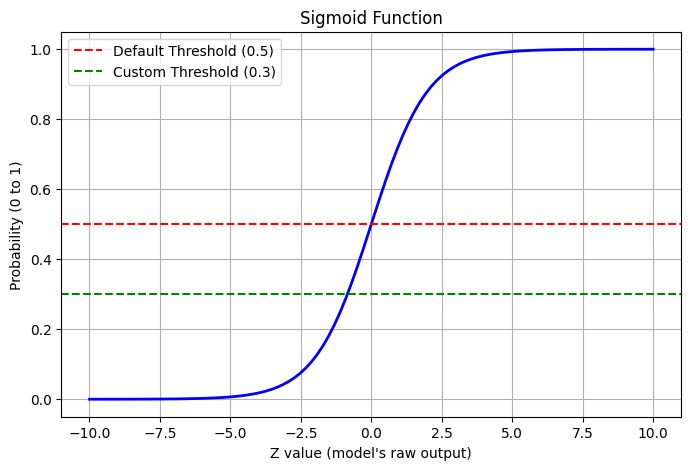

In [7]:
# Plot Sigmoid Function
z = np.linspace(-10, 10, 100)
# linspace() → creates 100 evenly spaced numbers from -10 to 10

sigmoid = 1 / (1 + np.exp(-z))
# sigmoid formula → converts any number to range 0 to 1
# this is what logistic regression uses internally!

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, color='blue', linewidth=2)
# plots the S-shaped sigmoid curve

plt.axhline(y=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
# horizontal red line at 0.5 → default decision boundary
# above 0.5 → predict Survived
# below 0.5 → predict Died

plt.axhline(y=0.3, color='green', linestyle='--', label='Custom Threshold (0.3)')
# green line at 0.3 → lower threshold
# catches MORE survivors but also more false alarms

plt.xlabel("Z value (model's raw output)")
plt.ylabel("Probability (0 to 1)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Default threshold = 0.5
Y_pred_05 = (Y_prob >= 0.5).astype(int)
# converts probabilities to 0/1 using 0.5 cutoff

# Custom threshold = 0.3
Y_pred_03 = (Y_prob >= 0.3).astype(int)
# converts probabilities to 0/1 using 0.3 cutoff
# lower threshold → more people predicted as Survived

print("With Threshold = 0.5 (Default):")
print(classification_report(Y_test, Y_pred_05,
      target_names=['Died', 'Survived']))

print("With Threshold = 0.3 (Custom):")
print(classification_report(Y_test, Y_pred_03,
      target_names=['Died', 'Survived']))


With Threshold = 0.5 (Default):
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

With Threshold = 0.3 (Custom):
              precision    recall  f1-score   support

        Died       0.88      0.72      0.80       105
    Survived       0.69      0.86      0.77        74

    accuracy                           0.78       179
   macro avg       0.79      0.79      0.78       179
weighted avg       0.80      0.78      0.78       179

